In [12]:
import json
import numpy as np
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
models_to_run_global = [
    "MLPGlobal",
    "GraphSAGEGlobal",
    "GUNetGlobal",
    "PointNetGlobal"
]

datasets = [
    "cls_model_35_default",
    "cls_model_35_normalized",
    "cls_model_35_centered",
    "cls_model_35_Extruded_default_thin_uniform",
    "cls_model_35_torus_default",
    "PointMAE_pretrain_default",
    "PointMAE_pretrain_normalized",
    "PointMAE_pretrain_centered",
    "PointMAE_pretrain_Extruded_normalized_thin_uniform",
    "PointMAE_pretrain_torus_normalized",
]


def compute_mean_std(json_path, key="test_mse_normalized"): #train_loss, val_loss, test_mse_normalized
    """
    Load a JSON file containing a list of runs and compute mean and std
    for the given metric key.
    """
    with open(json_path, "r") as f:
        data = json.load(f)

    values = [d[key] for d in data if key in d]

    # mean = np.mean(values)
    mean = values[-1]
    std  = 0

    return mean, std

DISPLAY_NAMES = {
    "baseline": "Baseline",
    "PointMAE_pretrain_default": "Default",
    "PointMAE_pretrain_normalized": "Standardized",
    "PointMAE_pretrain_centered": "Centered",
    "PointMAE_pretrain_Extruded_normalized_thin_uniform": "Standardized Extruded",
    "PointMAE_pretrain_Torus": "Standardized Torus",
    "PointMAE_pretrain_OT_3D": "OT 3D",
    "cls_model_35_default": "Default",
    "cls_model_35_normalized": "Standardized",
    "cls_model_35_centered": "Centered",
    "cls_model_35_Extruded_default_thin_uniform": "Default Extruded",
    "PointMAE_pretrain_torus_normalized": "Normalized Torus",
    "cls_model_35_OT_3D": "OT 3D",
    "cls_model_35_torus_default": "Default Torus",
}

def plot_empirical_grid(
    df,
    title="Test MSE gain comparison",
    ylabel="Relative MSE Reduction (%)",
):
    import matplotlib.pyplot as plt
    import numpy as np

    # =========================
    # CONFIG — edit here only
    # =========================
    model_cols = ["MLPGlobal", "GraphSAGEGlobal", "GUNetGlobal"]
    rows = [
        ("PointNet",  "cls_model_35"),
        ("PointMAE",  "PointMAE_pretrain"),
    ]

    FONT_TITLE   = 15
    FONT_ROW     = 15
    FONT_TICKS   = 15
    FONT_VALUE   = 15
    FONT_SUPTITLE = 20

    ROT_XTICKS = 25
    # =========================
    # FIGURE
    # =========================
    fig, axes = plt.subplots(
        nrows=len(rows),
        ncols=len(model_cols),
        figsize=(16, 8),
    )

    # =========================
    # PLOTTING
    # =========================
    for r, (row_name, dataset_prefix) in enumerate(rows):
        for c, model_name in enumerate(model_cols):
            ax = axes[r, c]

            sub = df[
                (df["model"] == model_name) &
                (df["dataset"].str.startswith(dataset_prefix))
            ]

            if sub.empty:
                ax.axis("off")
                continue

            x = np.arange(len(sub))
            y = sub["gain_pct_vs_baseline"].values
            labels = [
                DISPLAY_NAMES.get(d, d)
                for d in sub["dataset"].values
            ]

            # ax.bar(x, y, width=BAR_WIDTH)

            if r == 0:
                if c == 0:
                    ax.bar(x[[0]], y[[0]], color="tab:blue", label="2D")
                    ax.bar(x[1:3], y[1:3], color="tab:blue", alpha=0.6)
                    ax.bar(x[3:], y[3:], color="tab:red", alpha=0.6, label="3D")
                else: 
                    ax.bar(x[[0]], y[[0]], color="tab:blue")
                    ax.bar(x[1:3], y[1:3], color="tab:blue", alpha=0.6)
                    ax.bar(x[3:], y[3:], color="tab:red", alpha=0.6)

            elif r == 1:
                ax.bar(x[[1]], y[[1]], color="tab:blue")
                ax.bar(x[[0, 2]], y[[0, 2]], color="tab:blue", alpha=0.6)
                ax.bar(x[[3]], y[[3]], color="tab:red")       
                ax.bar(x[4:], y[4:], color="tab:red", alpha=0.6)


            ax.set_xticks(x)
            ax.tick_params(axis="y", labelsize=FONT_TICKS)
            ax.set_xticklabels(
                labels,
                rotation=ROT_XTICKS,
                ha="right",
                fontsize=FONT_TICKS
            )
            if c == 0:
                ax.set_ylabel(
                    row_name,
                    fontsize=FONT_ROW,
                    labelpad=20
                )
            if r == 0:
                ax.set_title(
                    model_name,
                    fontsize=FONT_TITLE,
                    pad=10
                )
    fig.suptitle(
        title,
        fontsize=FONT_SUPTITLE,
    )

    axes[0, 0].set_ylabel(
        "PointNet\n" + ylabel,
        fontsize=FONT_ROW
    )
    axes[1, 0].set_ylabel(
        "PointMAE\n" + ylabel,
        fontsize=FONT_ROW
    )
    fig.legend(frameon=False)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()


In [ ]:
import json
import numpy as np
import pandas as pd

rows = []

for model in models_to_run_global:
    base_model = model.replace("Global", "")

    # ---- baseline ----
    baseline_path = f"baseline_scarce_1600/metrics/scarce/{base_model}/{base_model}_log.json"
    mean, std = compute_mean_std(baseline_path)
    rows.append({
        "dataset": "baseline",
        "model": base_model,
        "mean_test_mse": mean,
        "std_test_mse": std,
    })

    for dataset in datasets:
        path = f"training_pipeline2_2/metrics/{dataset}/scarce/{model}/{model}_log.json"
        mean, std = compute_mean_std(path)
        rows.append({
            "dataset": dataset,
            "model": model,
            "mean_test_mse": mean,
            "std_test_mse": std,
        })

df = pd.DataFrame(rows)
df["base_model"] = df["model"].str.replace("Global", "", regex=False)
baseline_df = (
    df[df["dataset"] == "baseline"]
    .set_index("base_model")["mean_test_mse"]
)
df["baseline_mse"] = df["base_model"].map(baseline_df)
df["gain_pct_vs_baseline"] = (
    (df["baseline_mse"] - df["mean_test_mse"])
    / df["baseline_mse"]
    * 100
)
df.loc[df["dataset"] == "baseline", "gain_pct_vs_baseline"] = 0.0
df.head(25)





,dataset,model,mean_test_mse,std_test_mse,base_model,baseline_mse,gain_pct_vs_baseline
0,baseline,MLP,0.039132,0,MLP,0.039132,0.000000
1,cls_model_35_default,MLPGlobal,0.031551,0,MLP,0.039132,19.372926
2,cls_model_35_normalized,MLPGlobal,0.034671,0,MLP,0.039132,11.398802
3,cls_model_35_centered,MLPGlobal,0.033844,0,MLP,0.039132,13.512706
4,cls_model_35_Extruded_default_thin_uniform,MLPGlobal,0.029391,0,MLP,0.039132,24.891450
5,cls_model_35_torus_default,MLPGlobal,0.029050,0,MLP,0.039132,25.763794
6,PointMAE_pretrain_default,MLPGlobal,0.032138,0,MLP,0.039132,17.871793
7,PointMAE_pretrain_normalized,MLPGlobal,0.030256,0,MLP,0.039132,22.681286
8,PointMAE_pretrain_centered,MLPGlobal,0.033928,0,MLP,0.039132,13.297263
9,PointMAE_pretrain_Extruded_normalized_thin_uni...,MLPGlobal,0.025345,0,MLP,0.039132,35.232943


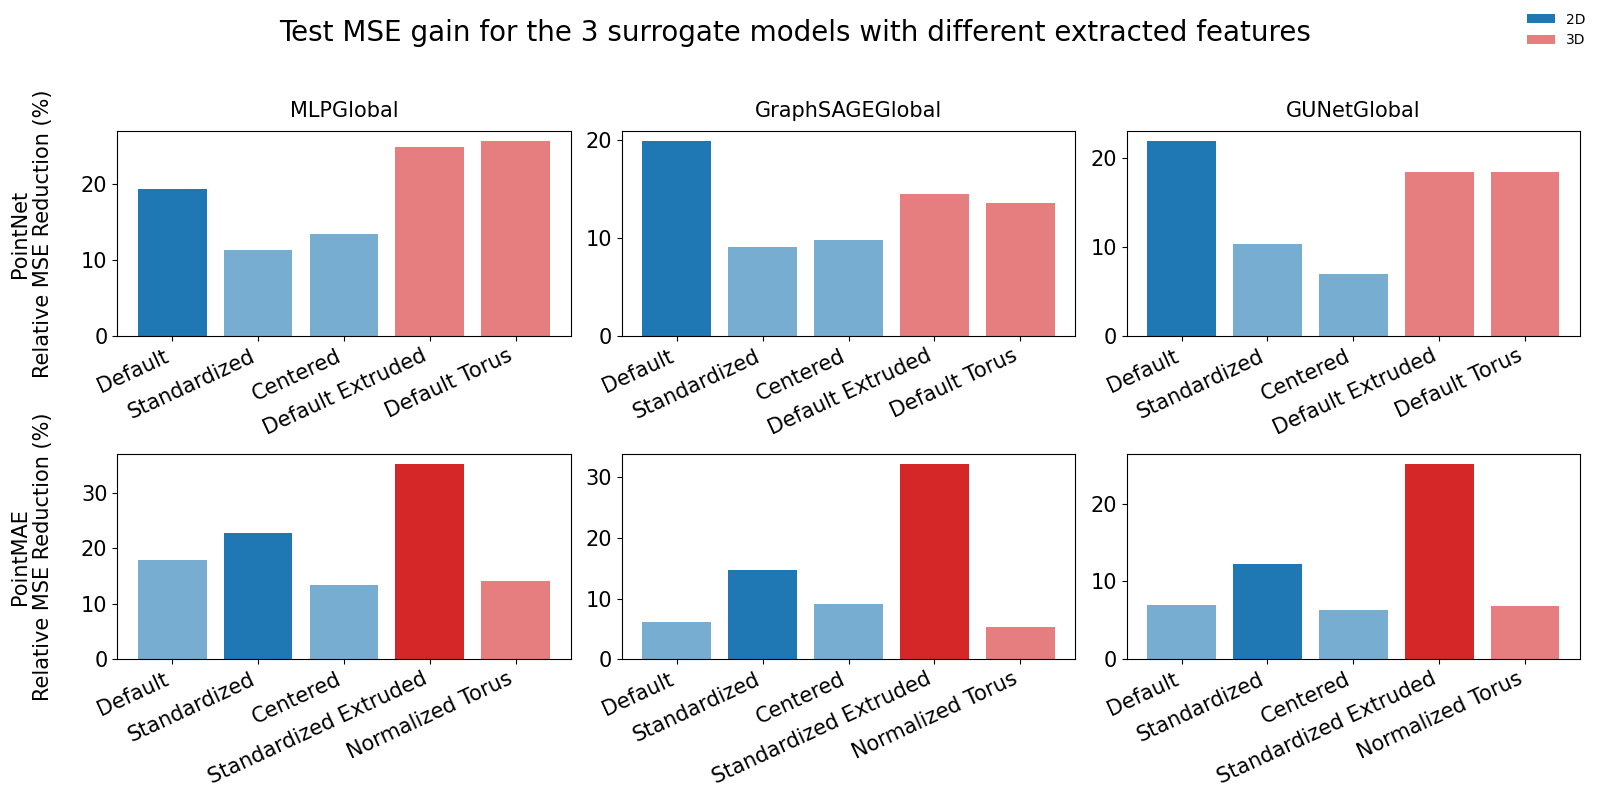

In [15]:
plot_empirical_grid(
    df,
    title="Test MSE gain for the 3 surrogate models with different extracted features",
)